## Comparative Analysis of Machine Learning and Deep Learning Models for EEG Motor Imagery Classification
In this lab, I work with the BCI Competition IV Dataset 2a to classify motor imagery EEG signals. The goal is to start with a simple binary task by distinguishing between imagined left-hand and right-hand movements. The workflow includes loading the EEG data, extracting events, segmenting the signals into epochs, selecting the relevant classes, and preparing the data for machine learning and deep learning experiments.

In [122]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [123]:
#Import EEG Processing Library
!pip install mne

##Importing Libraries

In [225]:
import mne
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau



##Checking the Files in the Dataset Folder

Before loading the EEG file, I verify that the dataset files are present in the folder uploaded to Google Drive.

In [125]:
folder_path = "/content/drive/MyDrive/EEG Signal Processing"
os.listdir(folder_path)

['A01T.gdf',
 'A01E.gdf',
 'A02E.gdf',
 'A03T.gdf',
 'A02T.gdf',
 'A03E.gdf',
 'A04E.gdf',
 'A05E.gdf',
 'A04T.gdf',
 'A05T.gdf',
 'A06E.gdf',
 'A06T.gdf',
 'A07E.gdf',
 'A07T.gdf',
 'A08T.gdf',
 'A09E.gdf',
 'A09T.gdf',
 'A08E.gdf']

In [126]:
file_path = "/content/drive/MyDrive/EEG Signal Processing/A01T.gdf"
print(file_path)

/content/drive/MyDrive/EEG Signal Processing/A01T.gdf


In [127]:
raw = mne.io.read_raw_gdf(file_path, preload=True)

Extracting GDF parameters from /content/drive/MyDrive/EEG Signal Processing/A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


In [128]:
print(raw.info)

<Info | 8 non-empty values
 bads: []
 ch_names: EEG-Fz, EEG-0, EEG-1, EEG-2, EEG-3, EEG-4, EEG-5, EEG-C3, EEG-6, ...
 chs: 25 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 100.0 Hz
 meas_date: 2005-01-17 12:00:00 UTC
 nchan: 25
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: A01, sex: 0, last_name: X, birthday: 1983-01-17>
>


In [129]:
events, event_id = mne.events_from_annotations(raw)

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]


In [130]:
print(event_id)

{np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}


## Creating EEG Epochs for Motor Imagery Classes

I focus on the motor imagery events only and create epochs while handling repeated markers appropriately.

In [131]:
epochs = mne.Epochs(
    raw,
    events,
    event_id=event_id,
    tmin=0,
    tmax=4,
    baseline=None,
    preload=True,
    event_repeated='drop'
)

Multiple event values for single event times found. Keeping the first occurrence and dropping all others.
Not setting metadata
585 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 585 events and 1001 original time points ...
0 bad epochs dropped


In [132]:
X = epochs.get_data()

In [133]:
y = epochs.events[:, -1]

In [134]:
print("EEG data shape:", X.shape)
print("Unique labels:", np.unique(y))

EEG data shape: (585, 25, 1001)
Unique labels: [ 5  6  7  8  9 10]


## Selecting Left-Hand and Right-Hand Motor Imagery Trials

The extracted epochs contain multiple event classes. For this project, I focus only on left-hand and right-hand motor imagery so that I can build a simpler binary classification model.

In [135]:
mask = np.isin(y, [7, 8])
X = X[mask]
y = y[mask]

In [136]:
print("Filtered EEG data shape:", X.shape)
print("Filtered labels:", np.unique(y))

Filtered EEG data shape: (144, 25, 1001)
Filtered labels: [7 8]


## Converting the Labels to Binary Form

To prepare the data for binary classification, I convert the labels into two categories: 0 for left-hand imagery and 1 for right-hand imagery.

In [137]:
y = np.where(y == 7, 0, 1)

In [138]:
print("Converted labels:", np.unique(y))

Converted labels: [0 1]


## Splitting the Data into Training and Testing Sets

I split the filtered EEG dataset into training and testing subsets so that I can train the model on one portion of the data and evaluate it on unseen samples.

In [139]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [140]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (115, 25, 1001)
X_test shape: (29, 25, 1001)
y_train shape: (115,)
y_test shape: (29,)


## Training a Baseline SVM Model

Before using a Convolutional Neural Network, I first train a Support Vector Machine as a baseline model. This helps establish an initial benchmark for the classification task.

In [141]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [200]:
svm_model = SVC()
svm_model.fit(X_train_flat, y_train)

SVC()

In [201]:
y_pred_svm = svm_model.predict(X_test_flat)

In [202]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.5172413793103449


In [146]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.55      0.40      0.46        15
           1       0.50      0.64      0.56        14

    accuracy                           0.52        29
   macro avg       0.52      0.52      0.51        29
weighted avg       0.52      0.52      0.51        29



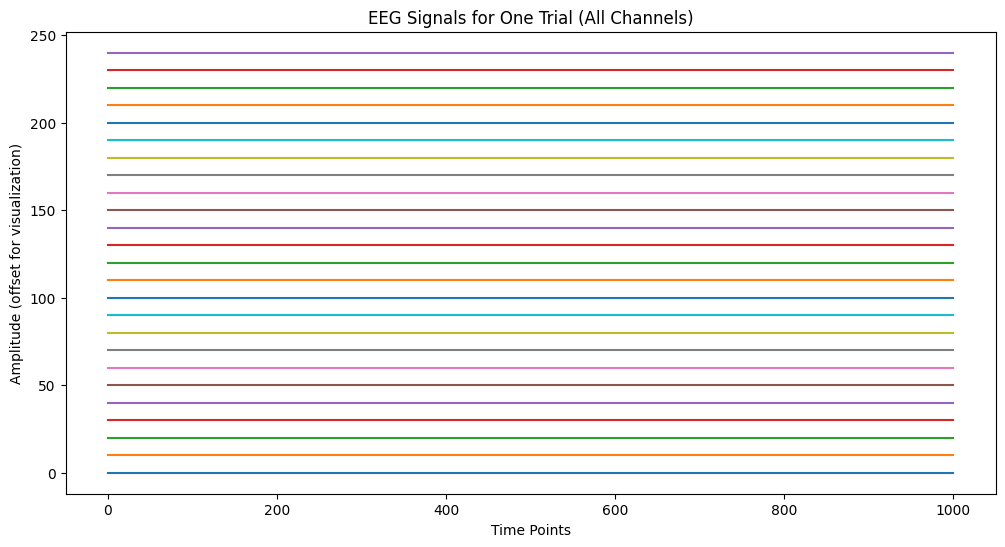

In [147]:
sample = X[0]  # first trial

plt.figure(figsize=(12, 6))
for i in range(sample.shape[0]):
    plt.plot(sample[i] + i*10)  # offset for clarity

plt.title("EEG Signals for One Trial (All Channels)")
plt.xlabel("Time Points")
plt.ylabel("Amplitude (offset for visualization)")
plt.show()

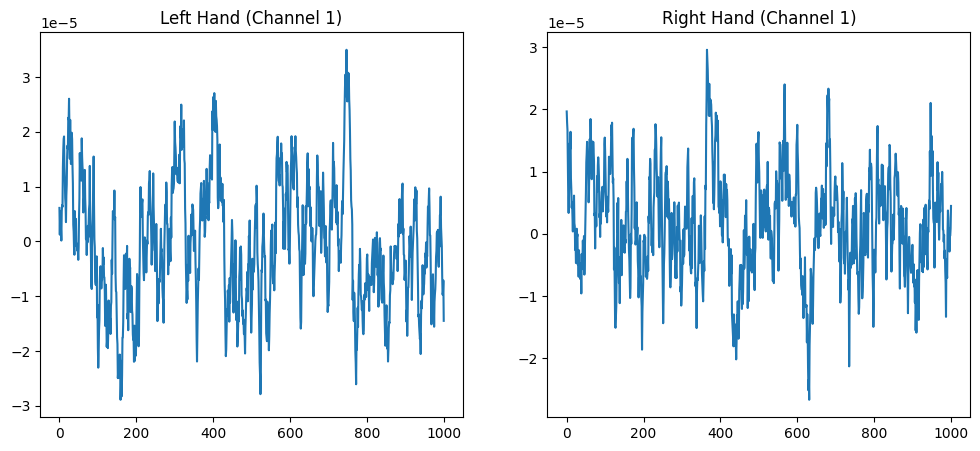

In [148]:
left_sample = X[y == 0][0]
right_sample = X[y == 1][0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(left_sample[0])
plt.title("Left Hand (Channel 1)")

plt.subplot(1, 2, 2)
plt.plot(right_sample[0])
plt.title("Right Hand (Channel 1)")

plt.show()

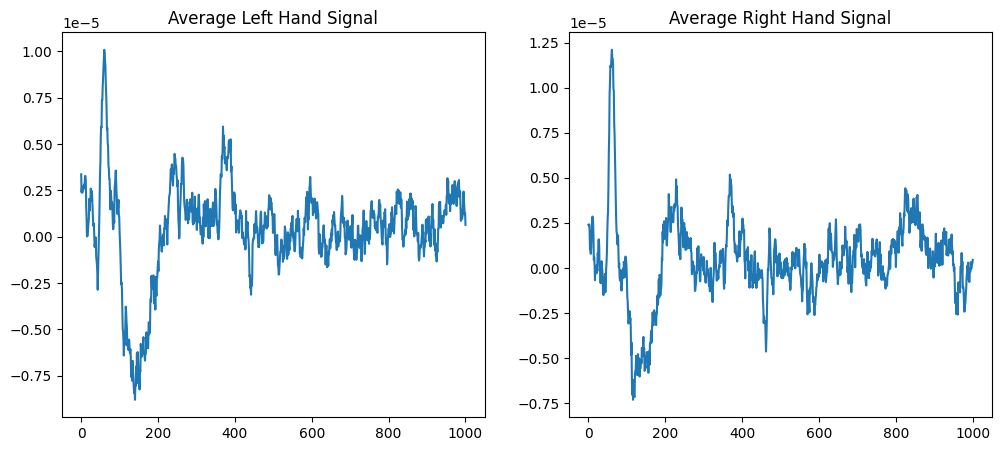

In [149]:
left_avg = X[y == 0].mean(axis=0)
right_avg = X[y == 1].mean(axis=0)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(left_avg[0])
plt.title("Average Left Hand Signal")

plt.subplot(1, 2, 2)
plt.plot(right_avg[0])
plt.title("Average Right Hand Signal")

plt.show()

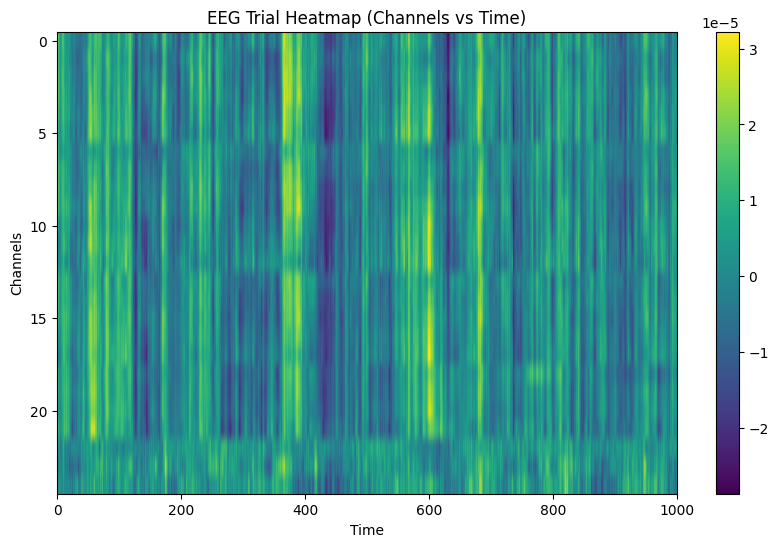

In [150]:
plt.figure(figsize=(10, 6))
plt.imshow(X[0], aspect='auto', cmap='viridis')
plt.colorbar()
plt.title("EEG Trial Heatmap (Channels vs Time)")
plt.xlabel("Time")
plt.ylabel("Channels")
plt.show()

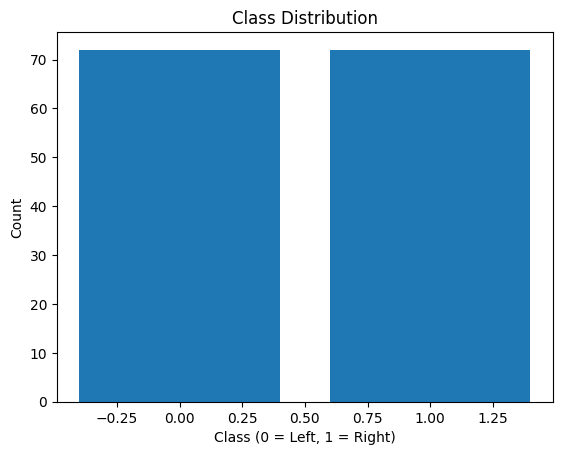

In [151]:
unique, counts = np.unique(y, return_counts=True)

plt.bar(unique, counts)
plt.title("Class Distribution")
plt.xlabel("Class (0 = Left, 1 = Right)")
plt.ylabel("Count")
plt.show()

## Rearranging the EEG Data for CNN Input

The EEG data is currently arranged as samples, channels, and time points. For a 1D Convolutional Neural Network, I rearrange it to samples, time points, and channels so that the model can learn temporal patterns across the EEG channels.

In [152]:
X_train_cnn = np.transpose(X_train, (0, 2, 1))
X_test_cnn = np.transpose(X_test, (0, 2, 1))
print("CNN training shape:", X_train_cnn.shape)
print("CNN testing shape:", X_test_cnn.shape)

CNN training shape: (115, 1001, 25)
CNN testing shape: (29, 1001, 25)


## Converting the Labels to Categorical Format

Since the CNN outputs probabilities for two classes, I convert the binary labels into categorical form.

In [153]:
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)
print("Categorical training labels shape:", y_train_cat.shape)
print("Categorical testing labels shape:", y_test_cat.shape)

Categorical training labels shape: (115, 2)
Categorical testing labels shape: (29, 2)


## Building First 1D CNN Model

I now define a simple 1D Convolutional Neural Network to learn temporal patterns from the EEG signals for left-hand and right-hand motor imagery classification.

In [154]:
cnn_model = Sequential([
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(X_train_cnn.shape[1], X_train_cnn.shape[2])
    ),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Conv1D(filters=64, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(2, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compiling the CNN Model

I compile the CNN using the Adam optimizer and categorical cross-entropy loss, since this is a two-class classification task with categorical labels.

In [155]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Reviewing the CNN Architecture

Before training, I inspect the structure of the CNN model to verify the layers and parameter counts.

In [156]:
cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 997, 32)        │         4,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 498, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 498, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 494, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 247, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 247, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 15808)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     1,011,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,026,242 (3.91 MB)

 Trainable params: 1,026,242 (3.91 MB)

 Non-trainable params: 0 (0.00 B)

## Training the CNN Model

I train the CNN on the EEG motor imagery training data and validate its performance on the testing set.

In [157]:
history = cnn_model.fit(
    X_train_cnn,
    y_train_cat,
    epochs=15,
    batch_size=16,
    validation_data=(X_test_cnn, y_test_cat),
    verbose=1
)

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 462ms/step - accuracy: 0.4783 - loss: 0.6957 - val_accuracy: 0.4828 - val_loss: 0.6939
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 215ms/step - accuracy: 0.5130 - loss: 0.6936 - val_accuracy: 0.5172 - val_loss: 0.6929
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.4783 - loss: 0.6938 - val_accuracy: 0.4828 - val_loss: 0.6936
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.5130 - loss: 0.6935 - val_accuracy: 0.4828 - val_loss: 0.6932
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 0.5478 - loss: 0.6929 - val_accuracy: 0.5172 - val_loss: 0.6931
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 0.4609 - loss: 0.6937 - val_accuracy: 0.5172 - val_loss: 0.6930
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.5130 - loss: 0.6929 - val_accuracy: 0.5172 - val_loss: 0.6929
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - accuracy: 0.5043 - loss: 0.6932 - val_accuracy: 0.5172 - val_loss:

## Evaluating the CNN Model

After training, I evaluate the model on the testing set to measure its final classification accuracy.

In [158]:
test_loss, test_accuracy = cnn_model.evaluate(X_test_cnn, y_test_cat)
print("CNN Test Loss:", test_loss)
print("CNN Test Accuracy:", test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5172 - loss: 0.6929
CNN Test Loss: 0.6928715109825134
CNN Test Accuracy: 0.517241358757019


## Building Second CNN Model with Normalized EEG Data

Before training the CNN, I normalize the EEG signals using the training set statistics. This helps the model learn more stable patterns across trials and channels.

In [159]:
mean = X_train.mean()
std = X_train.std()

X_train_norm = (X_train - mean) / (std + 1e-8)
X_test_norm = (X_test - mean) / (std + 1e-8)

In [160]:
X_train_cnn = np.transpose(X_train_norm, (0, 2, 1))
X_test_cnn = np.transpose(X_test_norm, (0, 2, 1))

In [161]:
print("Normalized CNN training shape:", X_train_cnn.shape)
print("Normalized CNN testing shape:", X_test_cnn.shape)

Normalized CNN training shape: (115, 1001, 25)
Normalized CNN testing shape: (29, 1001, 25)


## Defining an Improved 1D CNN

I define a slightly more stable CNN architecture for the normalized EEG signals.

In [162]:
cnn_model = Sequential([
    Conv1D(16, kernel_size=7, activation='relu', input_shape=(X_train_cnn.shape[1], X_train_cnn.shape[2])),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    Conv1D(32, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

In [163]:
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [164]:
cnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 995, 16)        │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 497, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 497, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 493, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 246, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 246, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 7872)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │       251,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257,410 (1005.51 KB)

 Trainable params: 257,410 (1005.51 KB)

 Non-trainable params: 0 (0.00 B)

## Training the Improved CNN

I train the normalized CNN for more epochs to give it a better chance to learn useful EEG patterns.

In [165]:
history = cnn_model.fit(
    X_train_cnn,
    y_train_cat,
    epochs=25,
    batch_size=8,
    validation_data=(X_test_cnn, y_test_cat),
    verbose=1
)

Epoch 1/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.4696 - loss: 1.3048 - val_accuracy: 0.5172 - val_loss: 0.7022
Epoch 2/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5478 - loss: 0.6949 - val_accuracy: 0.6552 - val_loss: 0.6930
Epoch 3/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7130 - loss: 0.6138 - val_accuracy: 0.5172 - val_loss: 0.6881
Epoch 4/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7391 - loss: 0.5671 - val_accuracy: 0.4483 - val_loss: 0.7099
Epoch 5/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8522 - loss: 0.4625 - val_accuracy: 0.5517 - val_loss: 0.7130
Epoch 6/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8522 - loss: 0.4067 - val_accuracy: 0.4483 - val_loss: 0.7641
Epoch 7/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8783 - loss: 0.3058 - val_accuracy: 0.4828 - val_loss: 0.7642
Epoch 8/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9304 - loss: 0.2004 - val_accuracy: 0.4828 - v

In [166]:
test_loss, test_accuracy = cnn_model.evaluate(X_test_cnn, y_test_cat)
print("Improved CNN Test Loss:", test_loss)
print("Improved CNN Test Accuracy:", test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5172 - loss: 1.6363
Improved CNN Test Loss: 1.6362948417663574
Improved CNN Test Accuracy: 0.517241358757019


##  Building Third CNN Model with Only EEG Channels

The dataset includes both EEG and EOG channels. Since the task is motor imagery classification, I retain only the first 22 EEG channels and remove the EOG channels.

In [167]:
X_eeg = X[:, :22, :]
print("EEG-only shape:", X_eeg.shape)

EEG-only shape: (144, 22, 1001)


## Splitting the EEG-Only Data

I split the EEG-only dataset into training and testing sets for model development and evaluation.

In [168]:
X_train, X_test, y_train, y_test = train_test_split(
    X_eeg, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (115, 22, 1001)
X_test shape: (29, 22, 1001)


## Normalizing the EEG-Only Data

I normalize the EEG signals using the training set mean and standard deviation so that the model learns from a more stable input scale.

In [169]:
mean = X_train.mean()
std = X_train.std()

X_train_norm = (X_train - mean) / (std + 1e-8)
X_test_norm = (X_test - mean) / (std + 1e-8)

## Rearranging the Data for CNN Input

For the 1D CNN, I rearrange the data from samples, channels, and time points to samples, time points, and channels.

In [170]:
X_train_cnn = np.transpose(X_train_norm, (0, 2, 1))
X_test_cnn = np.transpose(X_test_norm, (0, 2, 1))

print("CNN training shape:", X_train_cnn.shape)
print("CNN testing shape:", X_test_cnn.shape)

CNN training shape: (115, 1001, 22)
CNN testing shape: (29, 1001, 22)


## Defining the CNN Model

I define a simple 1D CNN for the EEG-only normalized motor imagery data.

In [171]:
cnn_model = Sequential([
    Conv1D(16, kernel_size=7, activation='relu', input_shape=(X_train_cnn.shape[1], X_train_cnn.shape[2])),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    Conv1D(32, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)              │ (None, 995, 16)        │         2,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 497, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 497, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 493, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 246, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 246, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 7872)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │       251,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257,074 (1004.20 KB)

 Trainable params: 257,074 (1004.20 KB)

 Non-trainable params: 0 (0.00 B)

## Training the EEG-Only CNN

I train the CNN on the normalized EEG-only data and evaluate it using the testing set.

In [172]:
history = cnn_model.fit(
    X_train_cnn,
    y_train_cat,
    epochs=25,
    batch_size=8,
    validation_data=(X_test_cnn, y_test_cat),
    verbose=1
)

Epoch 1/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.5130 - loss: 0.9227 - val_accuracy: 0.6207 - val_loss: 0.6843
Epoch 2/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5391 - loss: 0.7048 - val_accuracy: 0.4483 - val_loss: 0.6953
Epoch 3/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6522 - loss: 0.6377 - val_accuracy: 0.5172 - val_loss: 0.7333
Epoch 4/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7739 - loss: 0.5889 - val_accuracy: 0.5172 - val_loss: 0.7328
Epoch 5/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6783 - loss: 0.5628 - val_accuracy: 0.5172 - val_loss: 0.7040
Epoch 6/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7913 - loss: 0.4533 - val_accuracy: 0.5517 - val_loss: 0.7849
Epoch 7/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8435 - loss: 0.3670 - val_accuracy: 0.5172 - val_loss: 0.7706
Epoch 8/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6783 - loss: 0.5245 - val_accuracy: 0.4828 - v

In [173]:
test_loss, test_accuracy = cnn_model.evaluate(X_test_cnn, y_test_cat)
print("EEG-only CNN Test Loss:", test_loss)
print("EEG-only CNN Test Accuracy:", test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4828 - loss: 2.3287
EEG-only CNN Test Loss: 2.328669548034668
EEG-only CNN Test Accuracy: 0.48275861144065857


## Building Fourth CNN Model while applying Bandpass Filtering

Motor imagery EEG patterns are most informative in the mu and beta frequency bands, typically between 8 Hz and 30 Hz. To reduce noise and retain relevant neural activity, I apply a bandpass filter to the raw EEG signals before extracting events and epochs.

In [206]:
raw_filtered = raw.copy().filter(8., 30.)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)



## Extracting Events from the Filtered EEG Signal

After filtering the EEG signal, I extract the event markers again from the filtered recording. These event markers indicate the motor imagery classes present in the dataset.

In [207]:
events_filtered, event_id_filtered = mne.events_from_annotations(raw_filtered)
print(event_id_filtered)

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
{np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}


## Creating Epochs Using a More Informative Time Window

Instead of using the full 0 to 4 second interval, I use a more focused time window from 0.5 to 2.5 seconds. This removes the noisier early and late parts of the trial and keeps the segment where motor imagery activity is often more stable.

In [208]:
epochs_filtered = mne.Epochs(
    raw_filtered,
    events_filtered,
    event_id=event_id_filtered,
    tmin=0.5,
    tmax=2.5,
    baseline=None,
    preload=True,
    event_repeated='drop'
)

Multiple event values for single event times found. Keeping the first occurrence and dropping all others.
Not setting metadata
585 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 585 events and 501 original time points ...
0 bad epochs dropped


## Extracting EEG Trials and Labels

I extract the segmented EEG trials and their corresponding labels from the filtered epochs. These will be used as the input data and target classes for the classification task.

In [209]:
X_filtered = epochs_filtered.get_data()
y_filtered = epochs_filtered.events[:, -1]
X_filtered = epochs_filtered.get_data()
y_filtered = epochs_filtered.events[:, -1]

## Selecting Left-Hand and Right-Hand Motor Imagery Classes

To focus on the binary classification problem, I keep only the trials corresponding to left-hand and right-hand motor imagery.

In [210]:
mask = np.isin(y_filtered, [7, 8])
X_filtered = X_filtered[mask]
y_filtered = y_filtered[mask]
print("Binary EEG shape:", X_filtered.shape)
print("Binary labels:", np.unique(y_filtered))

Binary EEG shape: (144, 25, 501)
Binary labels: [7 8]


## Keeping Only EEG Channels

The dataset includes both EEG and EOG channels. Since EOG channels mainly capture eye movement artifacts, I remove them and retain only the first 22 EEG channels for training.

In [213]:
X_eeg = X_filtered[:, :22, :]
print("EEG-only shape:", X_eeg.shape)

EEG-only shape: (144, 22, 501)


## Converting Labels to Binary Form

I convert the class labels into binary form:
- 0 for left-hand motor imagery
- 1 for right-hand motor imagery

In [214]:
y_binary = np.where(y_filtered == 7, 0, 1)
print("Binary class labels:", np.unique(y_binary))

Binary class labels: [0 1]


## Splitting the Data into Training and Testing Sets

I divide the EEG dataset into training and testing subsets so that model performance can be evaluated on unseen data.

In [215]:
X_train, X_test, y_train, y_test = train_test_split(
    X_eeg,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

In [217]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (115, 22, 501)
X_test shape: (29, 22, 501)
y_train shape: (115,)
y_test shape: (29,)


## Normalizing the EEG Signals

To improve training stability, I normalize the EEG signals using the mean and standard deviation of the training set. This helps the CNN learn from a more consistent numerical scale.

In [219]:
mean = X_train.mean()
std = X_train.std()

X_train_norm = (X_train - mean) / (std + 1e-8)
X_test_norm = (X_test - mean) / (std + 1e-8)

print("Training mean after normalization (approx):", X_train_norm.mean())
print("Training std after normalization (approx):", X_train_norm.std())

Training mean after normalization (approx): 2.4227952821275655e-17
Training std after normalization (approx): 0.9980203985274627


## Rearranging the Data for CNN Input

The EEG data is currently arranged as samples, channels, and time points. For a 1D CNN, I rearrange it into samples, time points, and channels so that the model can learn temporal patterns more effectively.

In [221]:
X_train_cnn = np.transpose(X_train_norm, (0, 2, 1))
X_test_cnn = np.transpose(X_test_norm, (0, 2, 1))

print("CNN training shape:", X_train_cnn.shape)
print("CNN testing shape:", X_test_cnn.shape)

CNN training shape: (115, 501, 22)
CNN testing shape: (29, 501, 22)


## Converting Labels to Categorical Format

Since the CNN will output probabilities for two classes, I convert the binary labels into categorical form.

In [222]:
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

print("Categorical y_train shape:", y_train_cat.shape)
print("Categorical y_test shape:", y_test_cat.shape)

Categorical y_train shape: (115, 2)
Categorical y_test shape: (29, 2)


## Building the Improved 1D CNN Model

I define a stronger 1D CNN architecture with:
- multiple convolutional layers
- batch normalization
- dropout for regularization
- a dense classification head

This design is intended to improve stability and feature learning compared to the earlier simple CNN.

In [223]:
cnn_model_improved = Sequential([
    Conv1D(
        filters=16,
        kernel_size=7,
        activation='relu',
        input_shape=(X_train_cnn.shape[1], X_train_cnn.shape[2])
    ),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    Conv1D(filters=32, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    Conv1D(filters=64, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(2, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compiling the Improved CNN

I compile the CNN using the Adam optimizer and categorical cross-entropy loss for binary classification.

In [228]:
cnn_model_improved.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model_improved.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 495, 16)        │         2,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 495, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 247, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 247, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 243, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 243, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 121, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 121, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 119, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 119, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_14 (MaxPooling1D) │ (None, 59, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 59, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 3776)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │       241,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 253,586 (990.57 KB)

 Trainable params: 253,362 (989.70 KB)

 Non-trainable params: 224 (896.00 B)

## Defining Training Callbacks

To improve training, I use:
- **EarlyStopping** to stop training when validation loss stops improving
- **ReduceLROnPlateau** to reduce the learning rate when progress slows

In [229]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

## Training the Improved CNN

I train the improved CNN on the normalized EEG data using a smaller batch size and a larger number of epochs. The callbacks help prevent overfitting and improve convergence.

In [230]:
history_cnn_improved = cnn_model_improved.fit(
    X_train_cnn,
    y_train_cat,
    epochs=40,
    batch_size=8,
    validation_data=(X_test_cnn, y_test_cat),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - accuracy: 0.4957 - loss: 1.6221 - val_accuracy: 0.5172 - val_loss: 0.7878 - learning_rate: 0.0010
Epoch 2/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6522 - loss: 0.8183 - val_accuracy: 0.4828 - val_loss: 0.7956 - learning_rate: 0.0010
Epoch 3/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.7217 - loss: 0.8216 - val_accuracy: 0.5172 - val_loss: 0.7354 - learning_rate: 0.0010
Epoch 4/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8087 - loss: 0.4431 - val_accuracy: 0.5172 - val_loss: 0.7298 - learning_rate: 0.0010
Epoch 5/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8087 - loss: 0.3934 - val_accuracy: 0.5517 - val_loss: 0.7031 - learning_rate: 0.0010
Epoch 6/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8870 - loss: 0.2902 - val_accuracy: 0.5172 - val_loss: 0.7551 - learning_rate: 0.0010
Epoch 7/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8783 - loss: 0.2749 - val_a

In [231]:
cnn_model_improved = Sequential([
    Conv1D(8, kernel_size=5, activation='relu', input_shape=(X_train_cnn.shape[1], X_train_cnn.shape[2])),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(16, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Flatten(),
    Dense(16, activation='relu'),
    Dropout(0.5),

    Dense(2, activation='softmax')
])

cnn_model_improved.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

X_train_cnn_aug = X_train_cnn + np.random.normal(0, 0.01, X_train_cnn.shape)

history_cnn_improved = cnn_model_improved.fit(
    X_train_cnn_aug,
    y_train_cat,
    epochs=15,
    batch_size=8,
    validation_data=(X_test_cnn, y_test_cat),
    callbacks=callbacks,
    verbose=1
)

test_loss_cnn, test_accuracy_cnn = cnn_model_improved.evaluate(X_test_cnn, y_test_cat)
print("Improved CNN Test Loss:", test_loss_cnn)
print("Improved CNN Test Accuracy:", test_accuracy_cnn)

y_pred_prob_cnn = cnn_model_improved.predict(X_test_cnn)
y_pred_cnn = np.argmax(y_pred_prob_cnn, axis=1)

print(classification_report(y_test, y_pred_cnn))

Epoch 1/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.5739 - loss: 1.0563 - val_accuracy: 0.4828 - val_loss: 0.8556 - learning_rate: 0.0010
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4783 - loss: 0.7849 - val_accuracy: 0.4483 - val_loss: 0.7017 - learning_rate: 0.0010
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5043 - loss: 0.6987 - val_accuracy: 0.4828 - val_loss: 0.6958 - learning_rate: 0.0010
Epoch 4/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6087 - loss: 0.6800 - val_accuracy: 0.4138 - val_loss: 0.6979 - learning_rate: 0.0010
Epoch 5/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5739 - loss: 0.6837 - val_accuracy: 0.3448 - val_loss: 0.7065 - learning_rate: 0.0010
Epoch 6/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6348 - loss: 0.6723 - val_accuracy: 0.4483 - val_loss: 0.7074 - learning_rate: 5.0000e-04
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.4828 - loss: 0.6958
Improved CNN Test 

## Building an EEGNet Model

EEGNet is a compact neural network architecture designed specifically for EEG-based classification tasks. It is more suitable than a standard CNN for motor imagery EEG data because it learns both temporal and spatial EEG patterns efficiently.

In [174]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, DepthwiseConv2D, AveragePooling2D
from tensorflow.keras.layers import SeparableConv2D, BatchNormalization, Activation
from tensorflow.keras.layers import Dropout, Flatten, Dense
from tensorflow.keras.constraints import max_norm

## Preparing the EEG Data for EEGNet

EEGNet expects the input in a 4D format: samples, channels, time points, and kernels. I therefore reshape the EEG data accordingly.

In [175]:
X_eeg = X[:, :22, :]
print("EEG-only shape:", X_eeg.shape)


EEG-only shape: (144, 22, 1001)


In [176]:
X_train, X_test, y_train, y_test = train_test_split(
    X_eeg, y, test_size=0.2, random_state=42, stratify=y
)

In [177]:
mean = X_train.mean()
std = X_train.std()

X_train_norm = (X_train - mean) / (std + 1e-8)
X_test_norm = (X_test - mean) / (std + 1e-8)

In [178]:
X_train_eegnet = X_train_norm[..., np.newaxis]
X_test_eegnet = X_test_norm[..., np.newaxis]

In [179]:
print("EEGNet training shape:", X_train_eegnet.shape)
print("EEGNet testing shape:", X_test_eegnet.shape)

EEGNet training shape: (115, 22, 1001, 1)
EEGNet testing shape: (29, 22, 1001, 1)


In [180]:
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

## Defining the EEGNet Architecture

I now define a compact EEGNet-inspired model for binary motor imagery classification.

In [181]:
def build_eegnet(nb_classes, Chans=22, Samples=1001, dropoutRate=0.5, kernLength=64, F1=8, D=2, F2=16):
    input_main = Input((Chans, Samples, 1))

    block1 = Conv2D(
        F1,
        (1, kernLength),
        padding='same',
        use_bias=False
    )(input_main)
    block1 = BatchNormalization()(block1)

    block1 = DepthwiseConv2D(
        (Chans, 1),
        use_bias=False,
        depth_multiplier=D,
        depthwise_constraint=max_norm(1.)
    )(block1)
    block1 = BatchNormalization()(block1)
    block1 = Activation('elu')(block1)
    block1 = AveragePooling2D((1, 4))(block1)
    block1 = Dropout(dropoutRate)(block1)

    block2 = SeparableConv2D(
        F2,
        (1, 16),
        use_bias=False,
        padding='same'
    )(block1)
    block2 = BatchNormalization()(block2)
    block2 = Activation('elu')(block2)
    block2 = AveragePooling2D((1, 8))(block2)
    block2 = Dropout(dropoutRate)(block2)

    flatten = Flatten(name='flatten')(block2)

    dense = Dense(
        nb_classes,
        name='dense',
        kernel_constraint=max_norm(0.25)
    )(flatten)
    softmax = Activation('softmax', name='softmax')(dense)

    return Model(inputs=input_main, outputs=softmax)

## Initializing and Compiling EEGNet

I initialize the EEGNet model and compile it for binary classification.

In [182]:
eegnet_model = build_eegnet(nb_classes=2, Chans=22, Samples=1001)

In [183]:
eegnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [184]:
eegnet_model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 22, 1001, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 1001, 8)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 22, 1001, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 1, 1001, 16)    │           352 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1, 1001, 16)    │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 1, 1001, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 1, 250, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 1, 250, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 1, 250, 16)     │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1, 250, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1, 250, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 1, 31, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 1, 31, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 496)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           994 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Activation)            │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,530 (9.88 KB)

 Trainable params: 2,450 (9.57 KB)

 Non-trainable params: 80 (320.00 B)

## Training EEGNet

I train EEGNet on the normalized EEG motor imagery data and validate it on the test set.

In [185]:
history_eegnet = eegnet_model.fit(
    X_train_eegnet,
    y_train_cat,
    epochs=30,
    batch_size=8,
    validation_data=(X_test_eegnet, y_test_cat),
    verbose=1
)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 195ms/step - accuracy: 0.4087 - loss: 0.7644 - val_accuracy: 0.4483 - val_loss: 0.6913
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 171ms/step - accuracy: 0.5913 - loss: 0.6774 - val_accuracy: 0.6207 - val_loss: 0.6892
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 196ms/step - accuracy: 0.6609 - loss: 0.6302 - val_accuracy: 0.6897 - val_loss: 0.6896
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step - accuracy: 0.7304 - loss: 0.6041 - val_accuracy: 0.6897 - val_loss: 0.6862
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 175ms/step - accuracy: 0.7565 - loss: 0.5790 - val_accuracy: 0.6552 - val_loss: 0.6865
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 304ms/step - accuracy: 0.7391 - loss: 0.5563 - val_accuracy: 0.6552 - val_loss: 0.6843
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 205ms/step - accuracy: 0.7913 - loss: 0.5327 - val_accuracy: 0.5862 - val_loss: 0.6812
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step - accuracy: 0.7826 - loss: 0.5384 - val_accuracy: 0.

## Evaluating EEGNet

After training, I evaluate EEGNet on the testing set and inspect its accuracy.

In [186]:
test_loss, test_accuracy = eegnet_model.evaluate(X_test_eegnet, y_test_cat)
print("EEGNet Test Loss:", test_loss)
print("EEGNet Test Accuracy:", test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.8276 - loss: 0.4447
EEGNet Test Loss: 0.44470980763435364
EEGNet Test Accuracy: 0.8275862336158752


In [187]:
y_pred_prob = eegnet_model.predict(X_test_eegnet)
y_pred_eegnet = np.argmax(y_pred_prob, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step


In [188]:
print(classification_report(y_test, y_pred_eegnet))

              precision    recall  f1-score   support

           0       0.81      0.87      0.84        15
           1       0.85      0.79      0.81        14

    accuracy                           0.83        29
   macro avg       0.83      0.83      0.83        29
weighted avg       0.83      0.83      0.83        29



## Plotting EEGNet Accuracy Curves

I visualize the training and validation accuracy across epochs to assess model learning.

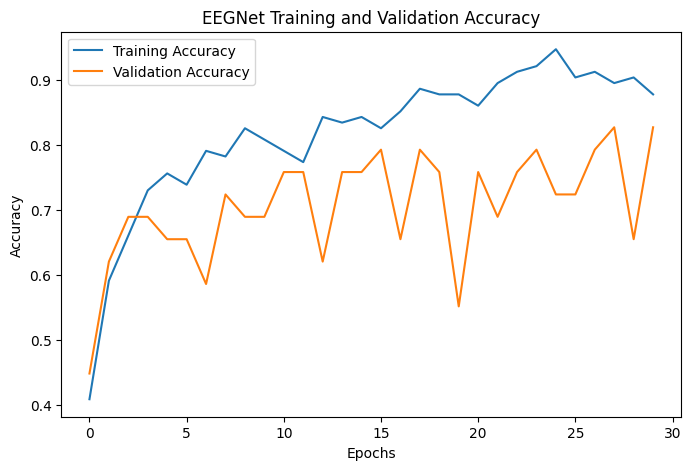

In [189]:
plt.figure(figsize=(8, 5))
plt.plot(history_eegnet.history['accuracy'], label='Training Accuracy')
plt.plot(history_eegnet.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('EEGNet Training and Validation Accuracy')
plt.legend()
plt.show()

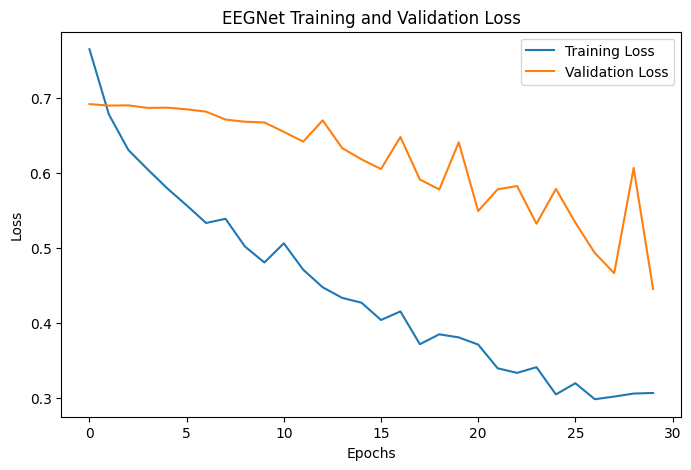

In [190]:
plt.figure(figsize=(8, 5))
plt.plot(history_eegnet.history['loss'], label='Training Loss')
plt.plot(history_eegnet.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('EEGNet Training and Validation Loss')
plt.legend()
plt.show()

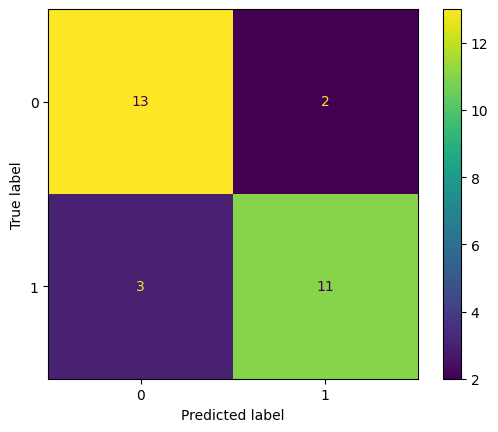

In [191]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_eegnet)
plt.show()

In [192]:

sample_trial = X[0][:22, :]
np.save("sample_trial.npy", sample_trial)

In [193]:
eegnet_model.save("eegnet_model.keras")

In [194]:
from google.colab import files

files.download("sample_trial.npy")
files.download("eegnet_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [196]:
y_pred_prob = eegnet_model.predict(X_test_eegnet)
confidences = np.max(y_pred_prob, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step


In [197]:
highest_idx = np.argmax(confidences)

print("Highest-confidence index:", highest_idx)
print("Confidence:", confidences[highest_idx])
print("Predicted probabilities:", y_pred_prob[highest_idx])
print("True label:", y_test[highest_idx])

Highest-confidence index: 18
Confidence: 0.90161896
Predicted probabilities: [0.90161896 0.09838099]
True label: 0


In [198]:
high_conf_trial = X_test[highest_idx]
np.save("high_conf_trial.npy", high_conf_trial)

In [199]:
files.download("high_conf_trial.npy")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>